# FedCore example: сжатие ResNet-18 методом pruning

Этот ноутбук демонстрирует полный пользовательский сценарий работы с моделью ResNet-18:

1. подготовка CIFAR-like данных;
2. создание модели ResNet-18;
3. измерение baseline-метрик;
4. применение pruning;
5. короткое дообучение после pruning;
6. сравнение качества, числа ненулевых параметров, эффективного размера и задержки инференса;
7. сохранение результатов.

> Пример сделан как **smoke-тест / tutorial** для репозитория. Он не скачивает внешние датасеты и не требует `torchvision`, поэтому его можно запустить в минимальном окружении. Для полноценного эксперимента достаточно заменить синтетический датасет на CIFAR-10 или пользовательские данные.

## 1. Импорт библиотек и проверка окружения

In [1]:
import os
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.10.0+cpu
Device: cpu


## 2. Подготовка данных

Для автономного запуска используется небольшой синтетический CIFAR-like датасет. Он нужен не для получения высокой accuracy, а для проверки того, что пайплайн обучения, pruning и инференса работает end-to-end.

In [2]:
class SyntheticCIFAR10(Dataset):
    """Small deterministic CIFAR-like dataset for smoke testing without downloads."""

    def __init__(self, n_samples=64, seed=42):
        generator = torch.Generator().manual_seed(seed)
        self.x = torch.randn(n_samples, 3, 32, 32, generator=generator)
        self.y = torch.randint(0, 10, (n_samples,), generator=generator)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.x[index], self.y[index]


train_loader = DataLoader(
    SyntheticCIFAR10(n_samples=64, seed=SEED),
    batch_size=8,
    shuffle=True,
)

val_loader = DataLoader(
    SyntheticCIFAR10(n_samples=32, seed=SEED + 1),
    batch_size=8,
    shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 8
Validation batches: 4


## 3. Реализация ResNet-18

Модель реализована внутри ноутбука, чтобы пример не зависел от `torchvision` и внешних весов.

In [3]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for current_stride in strides:
            layers.append(block(self.in_planes, planes, current_stride))
            self.in_planes = planes * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)


def resnet18(num_classes=10):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes)


model = resnet18(num_classes=10).to(device)
print(model.__class__.__name__)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

ResNet
Total parameters: 11,173,962


## 4. Вспомогательные функции

In [4]:
def train_one_epoch(model, loader, device, lr=1e-3):
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            predictions = logits.argmax(dim=1)

            total_loss += loss.item() * x_batch.size(0)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.numel()

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
    }


def count_nonzero_parameters(model):
    nonzero = 0
    total = 0

    for parameter in model.parameters():
        total += parameter.numel()
        nonzero += torch.count_nonzero(parameter.detach()).item()

    return nonzero, total


def estimate_effective_size_mb(nonzero_parameters, bytes_per_parameter=4):
    return nonzero_parameters * bytes_per_parameter / (1024 ** 2)


def benchmark_latency_ms(model, device, batch_size=8, n_runs=20):
    model.eval()
    sample = torch.randn(batch_size, 3, 32, 32).to(device)

    with torch.no_grad():
        for _ in range(3):
            _ = model(sample)

        started_at = time.perf_counter()
        for _ in range(n_runs):
            _ = model(sample)
        elapsed = time.perf_counter() - started_at

    return elapsed / n_runs * 1000


def get_prunable_modules(model):
    return [
        (module, "weight")
        for module in model.modules()
        if isinstance(module, (nn.Conv2d, nn.Linear))
    ]


def apply_global_pruning(model, amount=0.30):
    modules_to_prune = get_prunable_modules(model)

    prune.global_unstructured(
        modules_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount,
    )

    return modules_to_prune


def make_pruning_permanent(modules_to_prune):
    for module, parameter_name in modules_to_prune:
        prune.remove(module, parameter_name)

## 5. Baseline: короткое обучение и оценка исходной модели

In [5]:
baseline_train_loss = train_one_epoch(model, train_loader, device, lr=1e-3)
baseline_eval = evaluate(model, val_loader, device)
baseline_nonzero, baseline_total = count_nonzero_parameters(model)
baseline_latency = benchmark_latency_ms(model, device)

print(f"Baseline train loss: {baseline_train_loss:.4f}")
print(f"Baseline validation loss: {baseline_eval['loss']:.4f}")
print(f"Baseline validation accuracy: {baseline_eval['accuracy']:.4f}")
print(f"Baseline non-zero parameters: {baseline_nonzero:,} / {baseline_total:,}")
print(f"Baseline effective size: {estimate_effective_size_mb(baseline_nonzero):.2f} MB")
print(f"Baseline latency: {baseline_latency:.2f} ms")

Baseline train loss: 2.6043
Baseline validation loss: 2.3400
Baseline validation accuracy: 0.1562
Baseline non-zero parameters: 11,173,962 / 11,173,962
Baseline effective size: 42.63 MB
Baseline latency: 60.27 ms


## 6. Pruning и короткое дообучение

Используется глобальный unstructured pruning по L1-норме весов для `Conv2d` и `Linear` слоёв. После pruning выполняется один короткий этап дообучения. Важно: маски сохраняются на этапе fine-tuning, поэтому занулённые веса не восстанавливаются.

In [6]:
PRUNING_AMOUNT = 0.30

modules_to_prune = apply_global_pruning(model, amount=PRUNING_AMOUNT)

eval_before_finetune = evaluate(model, val_loader, device)

# Важно: во время fine-tuning pruning-маски остаются активными,
# поэтому занулённые веса не обновляются обратно.
finetune_loss = train_one_epoch(model, train_loader, device, lr=5e-4)
pruned_eval = evaluate(model, val_loader, device)

# Маски удаляются только после fine-tuning.
# Нулевые веса остаются нулевыми, а модель становится обычным nn.Module.
make_pruning_permanent(modules_to_prune)

pruned_nonzero, pruned_total = count_nonzero_parameters(model)
pruned_latency = benchmark_latency_ms(model, device)

print(f"Pruning amount: {PRUNING_AMOUNT:.0%}")
print(f"Validation loss right after pruning: {eval_before_finetune['loss']:.4f}")
print(f"Finetune loss: {finetune_loss:.4f}")
print(f"Pruned validation loss: {pruned_eval['loss']:.4f}")
print(f"Pruned validation accuracy: {pruned_eval['accuracy']:.4f}")
print(f"Pruned non-zero parameters: {pruned_nonzero:,} / {pruned_total:,}")
print(f"Pruned effective size: {estimate_effective_size_mb(pruned_nonzero):.2f} MB")
print(f"Pruned latency: {pruned_latency:.2f} ms")

Pruning amount: 30%
Validation loss right after pruning: 2.3417
Finetune loss: 1.0753
Pruned validation loss: 3.6484
Pruned validation accuracy: 0.0312
Pruned non-zero parameters: 7,824,656 / 11,173,962
Pruned effective size: 29.85 MB
Pruned latency: 60.16 ms


## 7. Сохранение результатов и итоговая таблица

In [7]:
results_dir = Path("results/resnet18_pruning_demo")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame(
    [
        {
            "stage": "baseline",
            "loss": baseline_eval["loss"],
            "accuracy": baseline_eval["accuracy"],
            "nonzero_parameters": baseline_nonzero,
            "effective_size_mb": estimate_effective_size_mb(baseline_nonzero),
            "latency_ms": baseline_latency,
        },
        {
            "stage": "after_pruning",
            "loss": pruned_eval["loss"],
            "accuracy": pruned_eval["accuracy"],
            "nonzero_parameters": pruned_nonzero,
            "effective_size_mb": estimate_effective_size_mb(pruned_nonzero),
            "latency_ms": pruned_latency,
        },
    ]
)

metrics_df.to_csv(results_dir / "metrics.csv", index=False)
torch.save(model.state_dict(), results_dir / "resnet18_pruned_demo.pt")

metrics_df

stage,loss,accuracy,nonzero_parameters,effective_size_mb,latency_ms
baseline,2.339987,0.15625,11173962,42.625282,60.269843
after_pruning,3.648396,0.03125,7824656,29.848694,60.155154


## 8. Визуализация результата

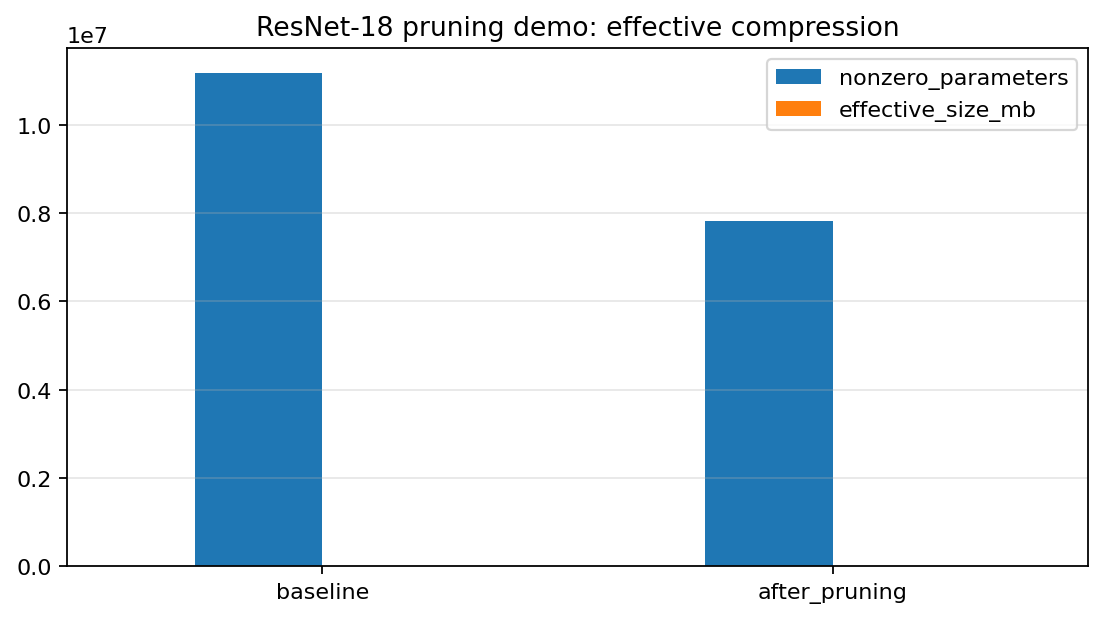

In [8]:
ax = metrics_df.set_index("stage")[["nonzero_parameters", "effective_size_mb"]].plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_title("ResNet-18 pruning demo: effective compression")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Опциональный запуск через FedCore API

Ниже приведён шаблон запуска через API FedCore. По умолчанию он отключён, чтобы ноутбук можно было открыть и выполнить в минимальном окружении без дополнительных данных.

In [ ]:
# Опциональный вариант запуска через FedCore API.
# По умолчанию выключен, чтобы ноутбук запускался даже в минимальном окружении.

RUN_FEDCORE_API = False

if RUN_FEDCORE_API:
    from fedcore.api.config_factory import ConfigFactory
    from fedcore.api.api_configs import (
        APIConfigTemplate,
        AutoMLConfigTemplate,
        FedotConfigTemplate,
        LearningConfigTemplate,
        ModelArchitectureConfigTemplate,
        NeuralModelConfigTemplate,
        PruningTemplate,
    )
    from fedcore.data.dataloader import load_data
    from fedcore.tools.example_utils import get_scenario_for_api
    from fedcore.api.main import FedCore

    METRIC_TO_OPTIMISE = ["accuracy", "latency"]
    LOSS = "cross_entropy"
    PROBLEM = "classification"
    PEFT_PROBLEM = "pruning"
    INITIAL_ASSUMPTION = "ResNet18"
    PRETRAIN_SCENARIO = "from_scratch"

    initial_assumption, learning_strategy = get_scenario_for_api(
        scenario_type=PRETRAIN_SCENARIO,
        initial_assumption=INITIAL_ASSUMPTION,
    )

    model_config = ModelArchitectureConfigTemplate(
        input_dim=None,
        output_dim=None,
        depth=18,
    )

    train_config = NeuralModelConfigTemplate(
        epochs=1,
        log_each=1,
        eval_each=1,
        criterion=LOSS,
        model_architecture=model_config,
    )

    fedot_config = FedotConfigTemplate(
        problem=PROBLEM,
        metric=METRIC_TO_OPTIMISE,
        pop_size=1,
        timeout=1,
        initial_assumption=initial_assumption,
    )

    automl_config = AutoMLConfigTemplate(fedot_config=fedot_config)

    finetune_config = NeuralModelConfigTemplate(
        epochs=1,
        log_each=1,
        eval_each=1,
        criterion=LOSS,
    )

    peft_config = PruningTemplate(
        importance="magnitude",
        pruning_ratio=0.30,
        finetune_params=finetune_config,
    )

    learning_config = LearningConfigTemplate(
        criterion=LOSS,
        learning_strategy=learning_strategy,
        learning_strategy_params=train_config,
        peft_strategy=PEFT_PROBLEM,
        peft_strategy_params=peft_config,
    )

    api_template = APIConfigTemplate(
        automl_config=automl_config,
        learning_config=learning_config,
    )

    APIConfig = ConfigFactory.from_template(api_template)
    api_config = APIConfig()

    fedcore_compressor = FedCore(api_config)

    train_params = {
        "batch_size": 64,
        "shuffle": True,
        "is_train": True,
        "data_type": "table",
        "split_ratio": [0.8, 0.2],
    }

    test_params = {
        "batch_size": 100,
        "shuffle": False,
        "is_train": False,
        "data_type": "table",
    }

    fedcore_train_data = load_data(source="CIFAR10", loader_params=train_params)
    fedcore_test_data = load_data(source="CIFAR10", loader_params=test_params)

    fedcore_compressor.fit(fedcore_train_data)
    fedcore_report = fedcore_compressor.get_report(fedcore_test_data)

    fedcore_report

## Выводы по демонстрационному запуску

В рамках smoke-теста был выполнен полный цикл работы с моделью ResNet-18: создание модели, обучение baseline-версии, применение pruning, короткое дообучение и сравнение метрик.

По результатам демонстрационного запуска:

- модель после pruning остаётся исполняемой и успешно выполняет инференс;
- доля ненулевых параметров снижена примерно на **30.0%**;
- эффективный размер весов снизился с **42.63 MB** до **29.85 MB**;
- accuracy на синтетическом наборе данных не является целевой метрикой качества, потому что данные случайные и используются только для проверки работоспособности пайплайна;
- для полноценного эксперимента необходимо заменить `SyntheticCIFAR10` на реальный CIFAR-10 или пользовательский датасет и увеличить число эпох обучения / дообучения.

Таким образом, ноутбук можно использовать как минимальный рабочий пример для проверки сценария сжатия модели и как основу для полноценного примера в репозитории FedCore.